# Task 2 — CNBC Headline NLP and JISDOR Direction Modeling

This notebook implements the complete Task 2 workflow using **CNBC headline titles only**. It re-runs the repository taxonomy against each title, preserves multi-label matches, aggregates leakage-controlled NLP features onto the complete JISDOR trading calendar, and compares naive, financial-only, NLP-only, and combined logistic-regression models.

The notebook never uses article bodies, GDELT text, publisher tags, a random split, or same-day return as a predictor. All learned text transformations are fitted on the training period only. Test data are evaluated only after the methodology and hyperparameters are fixed on validation data.

**LM prerequisite.** A genuine Loughran–McDonald Master Dictionary is required. If it is not already under data/external, download the CSV or XLSX from the [University of Notre Dame Software Repository for Accounting and Finance](https://sraf.nd.edu/loughranmcdonald-master-dictionary/) and set LM_LEXICON_PATH in Section 1. No substitute lexicon is used.

## 1. Imports and Configuration

The repository root is discovered from the current working directory, so the notebook works when launched from either the repository root or the notebooks directory. Configuration is centralized here for reproducibility.

In [22]:
from pathlib import Path
import html
import json
import re
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
DESIRED_SVD_COMPONENTS = 30
TFIDF_MAX_FEATURES = 20_000
TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15

CATEGORIES = [
    "armed_conflict",
    "sanctions",
    "trade_conflict",
    "energy_geopolitics",
    "political_instability",
    "monetary_geoeconomic",
]

# Optional explicit relative path, for example:
# LM_LEXICON_PATH = Path("data/external/Loughran-McDonald_MasterDictionary_1993-2025.csv")
LM_LEXICON_PATH = None

def find_repo_root(start: Path) -> Path:
    """Find the repository without relying on an absolute machine-specific path."""
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (
            (candidate / "data/processed/cnbc_headlines_aligned.csv").exists()
            and (candidate / "src/preprocessing/filter_cnbc.py").exists()
        ):
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current directory.")

ROOT = find_repo_root(Path.cwd())
HEADLINE_PATH = ROOT / "data/processed/cnbc_headlines_aligned.csv"
JISDOR_DAILY_PATH = ROOT / "data/processed/cnbc_jisdor_daily.csv"
TAXONOMY_PATH = ROOT / "config/geopolitical_topics.yaml"

FINAL_DAILY_PATH = ROOT / "data/processed/cnbc_jisdor_nlp_daily.csv"
MODELING_PATH = ROOT / "data/processed/cnbc_jisdor_nlp_modeling.csv"
DIRECT_MATCH_PATH = ROOT / "data/processed/cnbc_headlines_direct_match.csv"

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)

print(f"Repository root: {ROOT}")
print(f"Headline input: {HEADLINE_PATH.relative_to(ROOT)}")
print(f"Daily input: {JISDOR_DAILY_PATH.relative_to(ROOT)}")

Repository root: C:\Users\farhan\Documents\ChatGPT\NLP\NLP-Project_Event-Prediction-Analyzing-Impact-on-Dollar-Exchange-Rates
Headline input: data\processed\cnbc_headlines_aligned.csv
Daily input: data\processed\cnbc_jisdor_daily.csv


## 2. Load CNBC Headline Data

The aligned article file is the primary article-level input. Required fields are validated, while optional URL and audit fields are retained when present.

In [23]:
headlines = pd.read_csv(HEADLINE_PATH, low_memory=False)
required_headline_columns = {"title", "effective_trade_date", "return_pct"}
missing_required = required_headline_columns.difference(headlines.columns)
if missing_required:
    raise ValueError(f"Headline input is missing required columns: {sorted(missing_required)}")

headlines["effective_trade_date"] = pd.to_datetime(
    headlines["effective_trade_date"], errors="coerce"
).dt.normalize()
headlines["return_pct"] = pd.to_numeric(headlines["return_pct"], errors="coerce")

# A stable fallback key is used only when article_id is absent or blank.
if "article_id" in headlines.columns:
    article_ids = headlines["article_id"].astype("string").str.strip()
    fallback_keys = pd.Series(
        [f"source_row_{i}" for i in headlines.index],
        index=headlines.index,
        dtype="string",
    )
    headlines["article_key"] = article_ids.where(article_ids.notna() & article_ids.ne(""), fallback_keys)
else:
    headlines["article_key"] = pd.Series(
        [f"source_row_{i}" for i in headlines.index],
        index=headlines.index,
        dtype="string",
    )

print(f"Loaded {len(headlines):,} aligned CNBC headline rows.")
display(headlines.head(3))

Loaded 10,997 aligned CNBC headline rows.


,article_id,title,published_at_wib,effective_trade_date,matched_categories,original_url,previous_jisdor,jisdor,change_idr,return_pct,alignment_reason,article_key
0,7ecfaaee05db4e0a60bc6d0c26d1d4832f7a7c5d9b744f...,European stocks close higher as traders shrug ...,2021-09-01T12:09:00+07:00,2021-09-01,"[""monetary_geoeconomic""]",https://www.cnbc.com/2021/09/01/european-marke...,NaN,14284.0,NaN,NaN,same_day_before_cutoff,7ecfaaee05db4e0a60bc6d0c26d1d4832f7a7c5d9b744f...
1,3a1c724b06ff1aa9e50d563586492ad40a5af6cb1165c0...,U.S. relationship with Taliban unclear after e...,2021-09-02T04:17:51+07:00,2021-09-02,"[""armed_conflict""]",https://www.cnbc.com/2021/09/01/afghanistan-up...,14284.0,14281.0,-3.0,-0.021003,same_day_before_cutoff,3a1c724b06ff1aa9e50d563586492ad40a5af6cb1165c0...
2,fc41bf158096eae81871c5b82f31ad5e97c4f4dfae64b8...,Global investor Mark Mobius expects money to k...,2021-09-02T04:46:35+07:00,2021-09-02,"[""monetary_geoeconomic""]",https://www.cnbc.com/2021/09/01/mark-mobius-ex...,14284.0,14281.0,-3.0,-0.021003,same_day_before_cutoff,fc41bf158096eae81871c5b82f31ad5e97c4f4dfae64b8...


## 3. Data Quality Audit

Counts below are calculated from the actual input. The original matched_categories field is shown only as an audit trace of Task 1; it is not used to create Task 2 NLP labels.

In [24]:
duplicate_article_id_count = (
    int(headlines["article_id"].duplicated().sum())
    if "article_id" in headlines.columns
    else None
)
title_text = headlines["title"].fillna("").astype(str)
matched_examples = (
    headlines["matched_categories"].dropna().astype(str).drop_duplicates().head(8).tolist()
    if "matched_categories" in headlines.columns
    else ["Column not present"]
)

headline_audit = pd.Series({
    "row_count": len(headlines),
    "column_count": len(headlines.columns),
    "missing_title_count": int(title_text.str.strip().eq("").sum()),
    "missing_effective_trade_date_count": int(headlines["effective_trade_date"].isna().sum()),
    "missing_return_pct_count": int(headlines["return_pct"].isna().sum()),
    "duplicate_article_id_count": duplicate_article_id_count,
    "minimum_effective_trade_date": headlines["effective_trade_date"].min(),
    "maximum_effective_trade_date": headlines["effective_trade_date"].max(),
    "unique_effective_trade_dates": headlines["effective_trade_date"].nunique(),
    "unique_headlines": title_text.str.strip().nunique(),
})
display(headline_audit.to_frame("value"))
print("Columns:")
print(headlines.columns.tolist())
print("\nExamples from original Task 1 matched_categories:")
for value in matched_examples:
    print(" -", value)

,value
row_count,10997
column_count,12
missing_title_count,0
missing_effective_trade_date_count,0
missing_return_pct_count,1
duplicate_article_id_count,0
minimum_effective_trade_date,2021-09-01 00:00:00
maximum_effective_trade_date,2026-09-01 00:00:00
unique_effective_trade_dates,1185
unique_headlines,10976


Columns:
['article_id', 'title', 'published_at_wib', 'effective_trade_date', 'matched_categories', 'original_url', 'previous_jisdor', 'jisdor', 'change_idr', 'return_pct', 'alignment_reason', 'article_key']

Examples from original Task 1 matched_categories:
 - ["monetary_geoeconomic"]
 - ["armed_conflict"]
 - ["trade_conflict"]
 - ["political_instability"]
 - ["energy_geopolitics"]
 - ["sanctions"]
 - ["armed_conflict","political_instability"]
 - ["armed_conflict","monetary_geoeconomic"]


## 4. Headline-Based Geopolitical Classification Audit

Task 1 classifies candidates when taxonomy keywords match either a title or publisher keyword tags. Task 2 deliberately reuses the repository's taxonomy validation and token-boundary matcher but applies the rules to title text only. Each title can receive zero, one, or several categories; no mutually exclusive label is imposed.

In [25]:
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.preprocessing.filter_cnbc import keyword_pattern, validate_taxonomy

with TAXONOMY_PATH.open("r", encoding="utf-8") as handle:
    taxonomy = validate_taxonomy(yaml.safe_load(handle))

if set(taxonomy) != set(CATEGORIES):
    raise ValueError(
        "The configured taxonomy categories differ from the six Task 2 categories. "
        f"Configured: {sorted(taxonomy)}"
    )

compiled_taxonomy = {
    category: [(keyword, keyword_pattern(keyword)) for keyword in taxonomy[category]]
    for category in CATEGORIES
}

def title_taxonomy_matches(value) -> dict[str, list[str]]:
    """Return all configured title-only matches using Task 1 boundary semantics."""
    text = value if isinstance(value, str) else ""
    return {
        category: [keyword for keyword, pattern in patterns if pattern.search(text)]
        for category, patterns in compiled_taxonomy.items()
        if any(pattern.search(text) for _, pattern in patterns)
    }

headlines["headline_category_matches"] = headlines["title"].map(title_taxonomy_matches)
headlines["headline_categories"] = headlines["headline_category_matches"].map(list)
headlines["headline_taxonomy_match"] = headlines["headline_categories"].map(bool)

direct_count = int(headlines["headline_taxonomy_match"].sum())
no_direct_count = len(headlines) - direct_count
category_counts_article = (
    headlines.loc[headlines["headline_taxonomy_match"], ["article_key", "headline_categories"]]
    .explode("headline_categories")
    .groupby("headline_categories")["article_key"]
    .nunique()
    .reindex(CATEGORIES, fill_value=0)
    .astype(int)
)

print(f"Direct title-taxonomy matches: {direct_count:,}")
print(f"No direct title-taxonomy match: {no_direct_count:,}")
print(f"Direct title support: {direct_count / len(headlines):.2%}")
display(category_counts_article.rename("unique_headlines").to_frame())

comparison_columns = [
    column for column in
    ["title", "matched_categories", "headline_categories", "headline_category_matches"]
    if column in headlines.columns
]
display(headlines[comparison_columns].sample(min(8, len(headlines)), random_state=RANDOM_STATE))

Direct title-taxonomy matches: 9,008
No direct title-taxonomy match: 1,989
Direct title support: 81.91%


,unique_headlines
headline_categories,
armed_conflict,2357
sanctions,286
trade_conflict,2369
energy_geopolitics,333
political_instability,64
monetary_geoeconomic,3999


,title,matched_categories,headline_categories,headline_category_matches
107,UBS answers investors' toughest questions on i...,"[""monetary_geoeconomic""]",[monetary_geoeconomic],{'monetary_geoeconomic': ['inflation']}
8323,Wall Street sounds alarm on Europe’s economy o...,"[""trade_conflict""]",[trade_conflict],{'trade_conflict': ['tariff']}
2848,These economies are booming as Putin's war dri...,"[""armed_conflict""]",[armed_conflict],{'armed_conflict': ['war']}
8761,Treasury yields rise ahead of key inflation re...,"[""monetary_geoeconomic""]",[monetary_geoeconomic],{'monetary_geoeconomic': ['inflation']}
6492,Auto stocks fall as Trump tariffs spark trade ...,"[""armed_conflict"",""trade_conflict""]","[armed_conflict, trade_conflict]","{'armed_conflict': ['war'], 'trade_conflict': ..."
5294,Wall Street's scenarios for the Israel-Iran co...,"[""armed_conflict""]",[armed_conflict],{'armed_conflict': ['conflict']}
9880,‘All bets are off’: European borrowing costs h...,"[""armed_conflict"",""monetary_geoeconomic""]",[],{}
6605,Watch Fed Chair Powell testify live before the...,"[""monetary_geoeconomic""]",[],{}


## 5. Target Construction

The master JISDOR file is loaded now because its trading dates define both the target and all chronological partitions. The strict binary target is:

- direction = 1 when return_pct > 0
- direction = 0 when return_pct < 0
- undefined when return_pct is zero or missing

Zero and missing-return observations remain in the full daily audit data but are excluded from binary modeling.

In [26]:
jisdor_daily = pd.read_csv(JISDOR_DAILY_PATH, low_memory=False)
required_daily_columns = {"date", "jisdor", "return_pct"}
missing_daily = required_daily_columns.difference(jisdor_daily.columns)
if missing_daily:
    raise ValueError(f"JISDOR daily input is missing required columns: {sorted(missing_daily)}")

jisdor_daily["date"] = pd.to_datetime(jisdor_daily["date"], errors="raise").dt.normalize()
for column in ["jisdor", "previous_jisdor", "change_idr", "return_pct"]:
    if column in jisdor_daily.columns:
        jisdor_daily[column] = pd.to_numeric(jisdor_daily[column], errors="coerce")

if jisdor_daily["date"].duplicated().any():
    raise ValueError("The source JISDOR daily calendar contains duplicate dates.")
jisdor_daily = jisdor_daily.sort_values("date").reset_index(drop=True)

jisdor_daily["direction"] = pd.Series(pd.NA, index=jisdor_daily.index, dtype="Int64")
jisdor_daily.loc[jisdor_daily["return_pct"].gt(0), "direction"] = 1
jisdor_daily.loc[jisdor_daily["return_pct"].lt(0), "direction"] = 0

target_audit = pd.Series({
    "positive_return_days": int(jisdor_daily["return_pct"].gt(0).sum()),
    "negative_return_days": int(jisdor_daily["return_pct"].lt(0).sum()),
    "zero_return_days": int(jisdor_daily["return_pct"].eq(0).sum()),
    "missing_return_days": int(jisdor_daily["return_pct"].isna().sum()),
    "total_master_trading_days": len(jisdor_daily),
})
display(target_audit.to_frame("days"))

,days
positive_return_days,665
negative_return_days,523
zero_return_days,13
missing_return_days,1
total_master_trading_days,1202


## 6. Chronological Date Split

Unique source trading dates are sorted and partitioned approximately 70% / 15% / 15%. The split is created before fitting TF–IDF, SVD, scalers, or models. A date can belong to exactly one partition.

In [27]:
all_dates = pd.Index(jisdor_daily["date"].sort_values().unique())
n_dates = len(all_dates)
n_train_dates = int(np.floor(n_dates * TRAIN_FRACTION))
n_validation_dates = int(np.floor(n_dates * VALIDATION_FRACTION))

if min(n_train_dates, n_validation_dates, n_dates - n_train_dates - n_validation_dates) < 1:
    raise ValueError("Not enough trading dates for non-empty chronological splits.")

train_dates = all_dates[:n_train_dates]
validation_dates = all_dates[n_train_dates:n_train_dates + n_validation_dates]
test_dates = all_dates[n_train_dates + n_validation_dates:]

date_to_split = {
    **{date: "train" for date in train_dates},
    **{date: "validation" for date in validation_dates},
    **{date: "test" for date in test_dates},
}
jisdor_daily["split"] = jisdor_daily["date"].map(date_to_split)
headlines["split"] = headlines["effective_trade_date"].map(date_to_split)

split_rows = []
for split_name, dates in [
    ("train", train_dates),
    ("validation", validation_dates),
    ("test", test_dates),
]:
    split_rows.append({
        "split": split_name,
        "start_date": dates.min(),
        "end_date": dates.max(),
        "trading_dates": len(dates),
        "all_headline_rows": int(headlines["split"].eq(split_name).sum()),
        "strict_title_match_rows": int(
            (headlines["split"].eq(split_name) & headlines["headline_taxonomy_match"]).sum()
        ),
    })
split_summary = pd.DataFrame(split_rows).set_index("split")
display(split_summary)

assert train_dates.max() < validation_dates.min()
assert validation_dates.max() < test_dates.min()
assert set(train_dates).isdisjoint(validation_dates)
assert set(train_dates).isdisjoint(test_dates)
assert set(validation_dates).isdisjoint(test_dates)

,start_date,end_date,trading_dates,all_headline_rows,strict_title_match_rows
split,,,,,
train,2021-09-01,2025-02-18,841,6670,5262
validation,2025-02-19,2025-11-21,180,2415,2239
test,2025-11-24,2026-09-01,181,1912,1507


## 7. Headline Text Preprocessing

Preprocessing is intentionally light: HTML entities are decoded, obvious tags are stripped, text is lowercased, and whitespace is normalized. Negation, geopolitical entities, and economically meaningful vocabulary are preserved.

In [28]:
HTML_TAG_RE = re.compile(r"<[^>]+>")
WHITESPACE_RE = re.compile(r"\s+")

def preprocess_headline(value) -> str:
    """Light, deterministic normalization for CNBC title text."""
    if not isinstance(value, str):
        return ""
    text = html.unescape(value)
    text = HTML_TAG_RE.sub(" ", text)
    text = text.lower()
    return WHITESPACE_RE.sub(" ", text).strip()

strict_headlines = headlines.loc[
    headlines["headline_taxonomy_match"] & headlines["effective_trade_date"].notna()
].copy()

unknown_strict_dates = strict_headlines.loc[
    ~strict_headlines["effective_trade_date"].isin(all_dates),
    "effective_trade_date",
]
if not unknown_strict_dates.empty:
    raise ValueError(
        "Strict headlines contain effective dates outside the master JISDOR calendar: "
        f"{unknown_strict_dates.drop_duplicates().head().tolist()}"
    )

strict_headlines["title_clean"] = strict_headlines["title"].map(preprocess_headline)
if strict_headlines["title_clean"].eq("").any():
    warnings.warn("Some direct-taxonomy rows became empty after light preprocessing.", stacklevel=1)

display(strict_headlines[["title", "title_clean", "headline_categories"]].head(8))

,title,title_clean,headline_categories
0,European stocks close higher as traders shrug ...,european stocks close higher as traders shrug ...,[monetary_geoeconomic]
1,U.S. relationship with Taliban unclear after e...,u.s. relationship with taliban unclear after e...,[armed_conflict]
3,The U.S. would be ‘wise’ to cut tariffs on Chi...,the u.s. would be ‘wise’ to cut tariffs on chi...,[trade_conflict]
5,"JPMorgan downgrades AB InBev to underweight, s...","jpmorgan downgrades ab inbev to underweight, s...",[monetary_geoeconomic]
6,"Inflation could repeat the 1960s, when the Fed...","inflation could repeat the 1960s, when the fed...",[monetary_geoeconomic]
7,Afghanistan pullout sparks EU calls for more m...,afghanistan pullout sparks eu calls for more m...,[armed_conflict]
8,Guinea coup rattles iron ore and bauxite marke...,guinea coup rattles iron ore and bauxite marke...,[political_instability]
9,Op-ed: Investors need to keep perspective as t...,op-ed: investors need to keep perspective as t...,[monetary_geoeconomic]


## 8. TF-IDF Feature Extraction

The vectorizer is fitted only on strict title-matched headlines whose effective trading dates are in the training period. Validation and test titles are transformed with that fixed vocabulary and fixed inverse-document-frequency weights.

In [29]:
tfidf_fit_indices = strict_headlines.index[strict_headlines["split"].eq("train")]
if len(tfidf_fit_indices) == 0:
    raise ValueError("No strict title-matched training headlines are available for TF-IDF.")

tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    max_features=TFIDF_MAX_FEATURES,
    sublinear_tf=True,
    lowercase=False,  # preprocessing already lowercases deterministically
    token_pattern=r"(?u)\b\w\w+\b",
)

tfidf_matrices = {}
for split_name in ["train", "validation", "test"]:
    split_mask = strict_headlines["split"].eq(split_name)
    split_text = strict_headlines.loc[split_mask, "title_clean"]
    if split_name == "train":
        tfidf_matrices[split_name] = tfidf_vectorizer.fit_transform(split_text)
    else:
        tfidf_matrices[split_name] = tfidf_vectorizer.transform(split_text)

tfidf_vocabulary_size = len(tfidf_vectorizer.vocabulary_)
print(f"Training headlines used to fit TF-IDF: {len(tfidf_fit_indices):,}")
print(f"TF-IDF vocabulary size: {tfidf_vocabulary_size:,}")
print({name: matrix.shape for name, matrix in tfidf_matrices.items()})

Training headlines used to fit TF-IDF: 5,262
TF-IDF vocabulary size: 6,413
{'train': (5262, 6413), 'validation': (2239, 6413), 'test': (1507, 6413)}


## 9. TF-IDF Dimensionality Reduction

Raw sparse TF–IDF features are not carried into a daily sample of roughly twelve hundred observations. Thirty SVD components are requested as a parsimonious pre-specified representation; the code reduces that number only if matrix dimensions make thirty impossible. SVD is fitted on training TF–IDF only.

In [30]:
train_tfidf = tfidf_matrices["train"]
max_valid_components = min(train_tfidf.shape[0] - 1, train_tfidf.shape[1] - 1)
n_svd_components = min(DESIRED_SVD_COMPONENTS, max_valid_components)
if n_svd_components < 2:
    raise ValueError(
        f"Training TF-IDF matrix {train_tfidf.shape} is too small for meaningful SVD."
    )

svd = TruncatedSVD(n_components=n_svd_components, random_state=RANDOM_STATE)
svd_columns = [f"tfidf_svd_{i:02d}" for i in range(1, n_svd_components + 1)]

for split_name in ["train", "validation", "test"]:
    split_mask = strict_headlines["split"].eq(split_name)
    matrix = tfidf_matrices[split_name]
    transformed = svd.fit_transform(matrix) if split_name == "train" else svd.transform(matrix)
    strict_headlines.loc[split_mask, svd_columns] = transformed

print(f"SVD components retained: {n_svd_components}")
print(f"Cumulative explained variance ratio: {svd.explained_variance_ratio_.sum():.3f}")
display(strict_headlines[["title", "split", *svd_columns[:5]]].head())

SVD components retained: 30
Cumulative explained variance ratio: 0.111


,title,split,tfidf_svd_01,tfidf_svd_02,tfidf_svd_03,tfidf_svd_04,tfidf_svd_05
0,European stocks close higher as traders shrug ...,train,0.149063,0.242005,-0.082725,0.091058,-0.260281
1,U.S. relationship with Taliban unclear after e...,train,0.097485,-0.055285,-0.040936,0.052635,0.015205
3,The U.S. would be ‘wise’ to cut tariffs on Chi...,train,0.145233,-0.085221,-0.009333,0.003870,-0.011709
5,"JPMorgan downgrades AB InBev to underweight, s...",train,0.129125,-0.039757,0.004131,0.002793,-0.009277
6,"Inflation could repeat the 1960s, when the Fed...",train,0.189768,-0.078269,0.065542,-0.105621,-0.016791


## 10. Loughran-McDonald Sentiment

A genuine Loughran–McDonald master dictionary is mandatory. The loader accepts the official CSV or XLSX schema and treats a sentiment flag as active only when its numeric value is positive; negative flags denote words removed in later dictionary versions.

For headline i with N_i alphabetic tokens:

- positive ratio = positive-token count / N_i
- negative ratio = negative-token count / N_i
- uncertainty ratio = uncertainty-token count / N_i
- net sentiment = positive ratio − negative ratio

All ratios are zero when N_i is zero.

In [31]:
def resolve_lm_lexicon_path() -> Path:
    """Resolve one explicitly supplied or auto-detected genuine LM master dictionary."""
    if LM_LEXICON_PATH is not None:
        candidate = Path(LM_LEXICON_PATH)
        candidate = candidate if candidate.is_absolute() else ROOT / candidate
        if not candidate.exists():
            raise FileNotFoundError(f"Configured LM_LEXICON_PATH does not exist: {candidate}")
        return candidate

    external_dir = ROOT / "data/external"
    patterns = [
        "*Loughran*McDonald*MasterDictionary*.csv",
        "*Loughran*McDonald*MasterDictionary*.xlsx",
        "*Loughran*McDonald*MasterDictionary*.xls",
        "*LM*MasterDictionary*.csv",
        "*LM*MasterDictionary*.xlsx",
    ]
    found = sorted({
        path.resolve()
        for pattern in patterns
        for path in external_dir.glob(pattern)
        if path.is_file()
    }) if external_dir.exists() else []

    if not found:
        raise FileNotFoundError(
            "No genuine Loughran-McDonald master dictionary was found. "
            "Place the official CSV/XLSX under data/external/ or set LM_LEXICON_PATH "
            "in Section 1. The notebook intentionally does not substitute another lexicon."
        )
    if len(found) > 1:
        raise ValueError(
            "Multiple possible LM dictionaries were found. Set LM_LEXICON_PATH explicitly: "
            + ", ".join(str(path.relative_to(ROOT)) for path in found)
        )
    return found[0]

def load_lm_lexicon(path: Path) -> tuple[set[str], set[str], set[str], pd.DataFrame]:
    """Load positive, negative, and uncertainty sets from an LM master dictionary."""
    suffix = path.suffix.lower()
    if suffix == ".csv":
        try:
            frame = pd.read_csv(path, low_memory=False)
        except UnicodeDecodeError:
            frame = pd.read_csv(path, low_memory=False, encoding="latin-1")
            warnings.warn("LM CSV required latin-1 decoding.", stacklevel=1)
    elif suffix in {".xlsx", ".xls"}:
        frame = pd.read_excel(path)
    else:
        raise ValueError(f"Unsupported LM dictionary format: {suffix}")

    normalized_columns = {
        column: re.sub(r"[^a-z]", "", str(column).lower())
        for column in frame.columns
    }
    frame = frame.rename(columns=normalized_columns)
    required = {"word", "positive", "negative", "uncertainty"}
    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(
            f"LM dictionary is missing columns {sorted(missing)}; found {frame.columns.tolist()}"
        )

    words = frame["word"].astype("string").str.upper().str.strip()
    sets = []
    for label in ["positive", "negative", "uncertainty"]:
        active = pd.to_numeric(frame[label], errors="coerce").fillna(0).gt(0)
        sets.append(set(words.loc[active & words.notna() & words.ne("")]))
    if any(len(values) == 0 for values in sets):
        raise ValueError("One or more required LM sentiment sets are empty.")
    return sets[0], sets[1], sets[2], frame

lm_path = resolve_lm_lexicon_path()
lm_positive_words, lm_negative_words, lm_uncertainty_words, lm_dictionary = load_lm_lexicon(lm_path)
print(f"LM source: {lm_path.relative_to(ROOT)}")
print({
    "positive_words": len(lm_positive_words),
    "negative_words": len(lm_negative_words),
    "uncertainty_words": len(lm_uncertainty_words),
})

LM_TOKEN_RE = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")

def score_lm_sentiment(text: str) -> pd.Series:
    tokens = [token.upper() for token in LM_TOKEN_RE.findall(text or "")]
    word_count = len(tokens)
    positive_count = sum(token in lm_positive_words for token in tokens)
    negative_count = sum(token in lm_negative_words for token in tokens)
    uncertainty_count = sum(token in lm_uncertainty_words for token in tokens)
    denominator = word_count if word_count else 1
    positive_ratio = positive_count / denominator if word_count else 0.0
    negative_ratio = negative_count / denominator if word_count else 0.0
    uncertainty_ratio = uncertainty_count / denominator if word_count else 0.0
    return pd.Series({
        "lm_positive_count": positive_count,
        "lm_negative_count": negative_count,
        "lm_uncertainty_count": uncertainty_count,
        "lm_word_count": word_count,
        "lm_positive_ratio": positive_ratio,
        "lm_negative_ratio": negative_ratio,
        "lm_uncertainty_ratio": uncertainty_ratio,
        "lm_net_sentiment": positive_ratio - negative_ratio,
    })

lm_scores = strict_headlines["title_clean"].apply(score_lm_sentiment)
strict_headlines = pd.concat([strict_headlines, lm_scores], axis=1)
display(strict_headlines[[
    "title", "lm_word_count", "lm_positive_count", "lm_negative_count",
    "lm_uncertainty_count", "lm_net_sentiment"
]].head(10))

LM source: data\external\Loughran-McDonald_MasterDictionary_1993-2025.csv
{'positive_words': 347, 'negative_words': 2345, 'uncertainty_words': 297}


,title,lm_word_count,lm_positive_count,lm_negative_count,lm_uncertainty_count,lm_net_sentiment
0,European stocks close higher as traders shrug ...,10.0,0.0,1.0,0.0,-0.100000
1,U.S. relationship with Taliban unclear after e...,17.0,0.0,0.0,1.0,0.000000
3,The U.S. would be ‘wise’ to cut tariffs on Chi...,15.0,0.0,1.0,0.0,-0.066667
5,"JPMorgan downgrades AB InBev to underweight, s...",11.0,0.0,1.0,0.0,-0.090909
6,"Inflation could repeat the 1960s, when the Fed...",13.0,0.0,1.0,1.0,-0.076923
7,Afghanistan pullout sparks EU calls for more m...,9.0,0.0,0.0,1.0,0.000000
8,Guinea coup rattles iron ore and bauxite marke...,11.0,0.0,0.0,1.0,0.000000
9,Op-ed: Investors need to keep perspective as t...,12.0,0.0,0.0,0.0,0.000000
10,A sharp rise in wages is contributing to worri...,11.0,0.0,1.0,0.0,-0.090909
11,ECB to kick off its tapering debate as inflati...,14.0,0.0,0.0,0.0,0.000000


## 11. Multi-Label Category Expansion

Only strict direct-title matches enter the NLP methodology. Exploding the list allows one article to contribute once to every supported category. Duplicate article-category pairs are removed defensively, while the un-exploded strict article table remains available for overall daily features.

In [32]:
exploded_headlines = (
    strict_headlines
    .explode("headline_categories")
    .rename(columns={"headline_categories": "category"})
)
exploded_headlines = exploded_headlines.loc[
    exploded_headlines["category"].isin(CATEGORIES)
].copy()
exploded_headlines = exploded_headlines.drop_duplicates(
    ["effective_trade_date", "article_key", "category"]
)

if exploded_headlines.empty:
    raise ValueError("No strict headline-category rows remain after multi-label expansion.")

multi_label_audit = pd.Series({
    "strict_unique_articles": strict_headlines["article_key"].nunique(),
    "exploded_article_category_rows": len(exploded_headlines),
    "multi_label_articles": int(strict_headlines["headline_categories"].map(len).gt(1).sum()),
    "maximum_categories_on_one_article": int(strict_headlines["headline_categories"].map(len).max()),
})
display(multi_label_audit.to_frame("value"))
display(
    strict_headlines.loc[
        strict_headlines["headline_categories"].map(len).gt(1),
        ["title", "headline_categories"],
    ].head(10)
)

,value
strict_unique_articles,9008
exploded_article_category_rows,9408
multi_label_articles,394
maximum_categories_on_one_article,3


,title,headline_categories
169,Sudan’s military has seized power in a coup. H...,"[armed_conflict, political_instability]"
343,Not since Americans came home from World War I...,"[armed_conflict, monetary_geoeconomic]"
360,Rolling back U.S.-China tariffs would ease inf...,"[trade_conflict, monetary_geoeconomic]"
520,U.S. sanctions 8 people and entities following...,"[armed_conflict, sanctions]"
541,The U.S. hopes the threat of harsh sanctions d...,"[armed_conflict, sanctions]"
616,Russia is willing to go to war and incur sanct...,"[armed_conflict, sanctions]"
660,"Brits brace for 'perfect storm' of tax rises, ...","[energy_geopolitics, monetary_geoeconomic]"
676,EU raises inflation forecasts on supply disrup...,"[energy_geopolitics, monetary_geoeconomic]"
704,Investing Club: An upbeat week was quickly tak...,"[armed_conflict, monetary_geoeconomic]"
735,Charlie Munger calls inflation the No. 1 dange...,"[armed_conflict, monetary_geoeconomic]"


## 12. Daily × Category NLP Aggregation

Features are averaged by effective_trade_date × category and pivoted to one row per date. Overall news_count is computed from unique articles before category explosion, so multi-label articles do not inflate it. Category-count sums may legitimately exceed news_count.

In [33]:
sentiment_source_columns = [
    "lm_positive_ratio",
    "lm_negative_ratio",
    "lm_uncertainty_ratio",
    "lm_net_sentiment",
]
sentiment_output_names = {
    "lm_positive_ratio": "lm_positive_mean",
    "lm_negative_ratio": "lm_negative_mean",
    "lm_uncertainty_ratio": "lm_uncertainty_mean",
    "lm_net_sentiment": "lm_net_mean",
}

category_daily_parts = []
for category in CATEGORIES:
    subset = exploded_headlines.loc[exploded_headlines["category"].eq(category)]
    named_aggregations = {
        "count": ("article_key", "nunique"),
        **{
            output_name: (source_name, "mean")
            for source_name, output_name in sentiment_output_names.items()
        },
        **{
            f"{component}_mean": (component, "mean")
            for component in svd_columns
        },
    }
    category_daily = (
        subset.groupby("effective_trade_date")
        .agg(**named_aggregations)
        .rename(columns=lambda column: f"{category}_{column}")
    )
    category_daily_parts.append(category_daily)

category_daily_wide = pd.concat(category_daily_parts, axis=1).sort_index()

strict_unique_articles = (
    strict_headlines.sort_values(["effective_trade_date", "article_key"])
    .drop_duplicates(["effective_trade_date", "article_key"])
)
overall_aggregations = {
    "news_count": ("article_key", "nunique"),
    **{
        output_name: (source_name, "mean")
        for source_name, output_name in sentiment_output_names.items()
    },
    **{
        f"overall_{component}_mean": (component, "mean")
        for component in svd_columns
    },
}
overall_daily = (
    strict_unique_articles.groupby("effective_trade_date")
    .agg(**overall_aggregations)
    .sort_index()
)

daily_nlp = overall_daily.join(category_daily_wide, how="outer").sort_index()
daily_nlp.index.name = "date"

expected_unique_by_date = (
    strict_headlines.groupby("effective_trade_date")["article_key"].nunique().astype(int)
)
observed_unique_by_date = (
    daily_nlp["news_count"].fillna(0).astype(int).reindex(expected_unique_by_date.index)
)
pd.testing.assert_series_equal(
    observed_unique_by_date,
    expected_unique_by_date.rename("news_count"),
    check_names=True,
)

print(f"NLP-covered trading dates: {daily_nlp.index.nunique():,}")
print(f"Sum of unique daily articles: {int(daily_nlp['news_count'].sum()):,}")
display(daily_nlp.head())

NLP-covered trading dates: 1,166
Sum of unique daily articles: 9,008


,news_count,lm_positive_mean,lm_negative_mean,lm_uncertainty_mean,lm_net_mean,overall_tfidf_svd_01_mean,overall_tfidf_svd_02_mean,overall_tfidf_svd_03_mean,overall_tfidf_svd_04_mean,overall_tfidf_svd_05_mean,overall_tfidf_svd_06_mean,overall_tfidf_svd_07_mean,overall_tfidf_svd_08_mean,overall_tfidf_svd_09_mean,overall_tfidf_svd_10_mean,overall_tfidf_svd_11_mean,overall_tfidf_svd_12_mean,overall_tfidf_svd_13_mean,overall_tfidf_svd_14_mean,overall_tfidf_svd_15_mean,overall_tfidf_svd_16_mean,overall_tfidf_svd_17_mean,overall_tfidf_svd_18_mean,overall_tfidf_svd_19_mean,overall_tfidf_svd_20_mean,overall_tfidf_svd_21_mean,overall_tfidf_svd_22_mean,overall_tfidf_svd_23_mean,overall_tfidf_svd_24_mean,overall_tfidf_svd_25_mean,overall_tfidf_svd_26_mean,overall_tfidf_svd_27_mean,overall_tfidf_svd_28_mean,overall_tfidf_svd_29_mean,overall_tfidf_svd_30_mean,armed_conflict_count,armed_conflict_lm_positive_mean,armed_conflict_lm_negative_mean,armed_conflict_lm_uncertainty_mean,armed_conflict_lm_net_mean,armed_conflict_tfidf_svd_01_mean,armed_conflict_tfidf_svd_02_mean,armed_conflict_tfidf_svd_03_mean,armed_conflict_tfidf_svd_04_mean,armed_conflict_tfidf_svd_05_mean,armed_conflict_tfidf_svd_06_mean,armed_conflict_tfidf_svd_07_mean,armed_conflict_tfidf_svd_08_mean,armed_conflict_tfidf_svd_09_mean,armed_conflict_tfidf_svd_10_mean,armed_conflict_tfidf_svd_11_mean,armed_conflict_tfidf_svd_12_mean,armed_conflict_tfidf_svd_13_mean,armed_conflict_tfidf_svd_14_mean,armed_conflict_tfidf_svd_15_mean,armed_conflict_tfidf_svd_16_mean,armed_conflict_tfidf_svd_17_mean,armed_conflict_tfidf_svd_18_mean,armed_conflict_tfidf_svd_19_mean,armed_conflict_tfidf_svd_20_mean,...,political_instability_tfidf_svd_06_mean,political_instability_tfidf_svd_07_mean,political_instability_tfidf_svd_08_mean,political_instability_tfidf_svd_09_mean,political_instability_tfidf_svd_10_mean,political_instability_tfidf_svd_11_mean,political_instability_tfidf_svd_12_mean,political_instability_tfidf_svd_13_mean,political_instability_tfidf_svd_14_mean,political_instability_tfidf_svd_15_mean,political_instability_tfidf_svd_16_mean,political_instability_tfidf_svd_17_mean,political_instability_tfidf_svd_18_mean,political_instability_tfidf_svd_19_mean,political_instability_tfidf_svd_20_mean,political_instability_tfidf_svd_21_mean,political_instability_tfidf_svd_22_mean,political_instability_tfidf_svd_23_mean,political_instability_tfidf_svd_24_mean,political_instability_tfidf_svd_25_mean,political_instability_tfidf_svd_26_mean,political_instability_tfidf_svd_27_mean,political_instability_tfidf_svd_28_mean,political_instability_tfidf_svd_29_mean,political_instability_tfidf_svd_30_mean,monetary_geoeconomic_count,monetary_geoeconomic_lm_positive_mean,monetary_geoeconomic_lm_negative_mean,monetary_geoeconomic_lm_uncertainty_mean,monetary_geoeconomic_lm_net_mean,monetary_geoeconomic_tfidf_svd_01_mean,monetary_geoeconomic_tfidf_svd_02_mean,monetary_geoeconomic_tfidf_svd_03_mean,monetary_geoeconomic_tfidf_svd_04_mean,monetary_geoeconomic_tfidf_svd_05_mean,monetary_geoeconomic_tfidf_svd_06_mean,monetary_geoeconomic_tfidf_svd_07_mean,monetary_geoeconomic_tfidf_svd_08_mean,monetary_geoeconomic_tfidf_svd_09_mean,monetary_geoeconomic_tfidf_svd_10_mean,monetary_geoeconomic_tfidf_svd_11_mean,monetary_geoeconomic_tfidf_svd_12_mean,monetary_geoeconomic_tfidf_svd_13_mean,monetary_geoeconomic_tfidf_svd_14_mean,monetary_geoeconomic_tfidf_svd_15_mean,monetary_geoeconomic_tfidf_svd_16_mean,monetary_geoeconomic_tfidf_svd_17_mean,monetary_geoeconomic_tfidf_svd_18_mean,monetary_geoeconomic_tfidf_svd_19_mean,monetary_geoeconomic_tfidf_svd_20_mean,monetary_geoeconomic_tfidf_svd_21_mean,monetary_geoeconomic_tfidf_svd_22_mean,monetary_geoeconomic_tfidf_svd_23_mean,monetary_geoeconomic_tfidf_svd_24_mean,monetary_geoeconomic_tfidf_svd_25_mean,monetary_geoeconomic_tfidf_svd_26_mean,monetary_geoeconomic_tfidf_svd_27_mean,monetary_geoeconomic_tfidf_svd_28_mean,monetary_geoeconomic_tfidf_svd_29_mean,monetary_geoeconomic_tf

## 13. Merge with Complete JISDOR Trading Calendar

The source cnbc_jisdor_daily.csv is the master calendar. Existing Task 1 count columns are dropped before merging because they may include publisher-tag matches; Task 2 replaces them with strict title-only counts. The left join preserves every and only actual JISDOR observation. Zero-valued NLP aggregates on no-news days are explicitly distinguished by has_news = 0.

In [34]:
source_count_columns = [
    "news_count",
    *[f"{category}_count" for category in CATEGORIES],
]
calendar_base = jisdor_daily.drop(
    columns=[column for column in source_count_columns if column in jisdor_daily.columns]
).copy()

final_daily = calendar_base.merge(
    daily_nlp.reset_index(),
    on="date",
    how="left",
    validate="one_to_one",
    sort=True,
)

category_count_columns = [f"{category}_count" for category in CATEGORIES]
count_columns = ["news_count", *category_count_columns]
for column in count_columns:
    if column not in final_daily.columns:
        final_daily[column] = 0
    final_daily[column] = final_daily[column].fillna(0).astype(int)

final_daily["has_news"] = final_daily["news_count"].gt(0).astype(int)

category_sentiment_columns = [
    f"{category}_{metric}"
    for category in CATEGORIES
    for metric in [
        "lm_positive_mean",
        "lm_negative_mean",
        "lm_uncertainty_mean",
        "lm_net_mean",
    ]
]
category_svd_columns = [
    f"{category}_{component}_mean"
    for category in CATEGORIES
    for component in svd_columns
]
overall_sentiment_columns = [
    "lm_positive_mean",
    "lm_negative_mean",
    "lm_uncertainty_mean",
    "lm_net_mean",
]
overall_svd_columns = [f"overall_{component}_mean" for component in svd_columns]

nlp_continuous_columns = [
    *overall_sentiment_columns,
    *overall_svd_columns,
    *category_sentiment_columns,
    *category_svd_columns,
]
for column in nlp_continuous_columns:
    if column not in final_daily.columns:
        final_daily[column] = 0.0
    final_daily[column] = pd.to_numeric(final_daily[column], errors="coerce").fillna(0.0)

nlp_feature_columns = [
    "news_count",
    "has_news",
    *category_count_columns,
    *overall_sentiment_columns,
    *overall_svd_columns,
    *category_sentiment_columns,
    *category_svd_columns,
]

assert len(final_daily) == len(jisdor_daily)
assert final_daily["date"].is_unique
assert final_daily["date"].is_monotonic_increasing

print(f"Source JISDOR rows: {len(jisdor_daily):,}")
print(f"Final rows after left join: {len(final_daily):,}")
print(f"Days with strict title-matched news: {int(final_daily['has_news'].sum()):,}")
print(f"Days without strict title-matched news: {int(final_daily['has_news'].eq(0).sum()):,}")

Source JISDOR rows: 1,202
Final rows after left join: 1,202
Days with strict title-matched news: 1,166
Days without strict title-matched news: 36


## 14. Historical Financial Features

Every financial predictor is lagged. Rolling statistics are calculated from return_pct shifted by one observation, so the current day's return and direction never enter its predictors. The strict modeling table excludes undefined targets and rows lacking any required historical financial feature; the full calendar remains untouched.

Full daily audit rows retained: 1,202
Strict binary modeling rows: 1,178


C:\Users\farhan\AppData\Local\Temp\ipykernel_36000\4146665283.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_daily["return_lag_1"] = final_daily["return_pct"].shift(1)
C:\Users\farhan\AppData\Local\Temp\ipykernel_36000\4146665283.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_daily["return_lag_2"] = final_daily["return_pct"].shift(2)
C:\Users\farhan\AppData\Local\Temp\ipykernel_36000\4146665283.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` ma

,rows
split,
train,823
validation,178
test,177


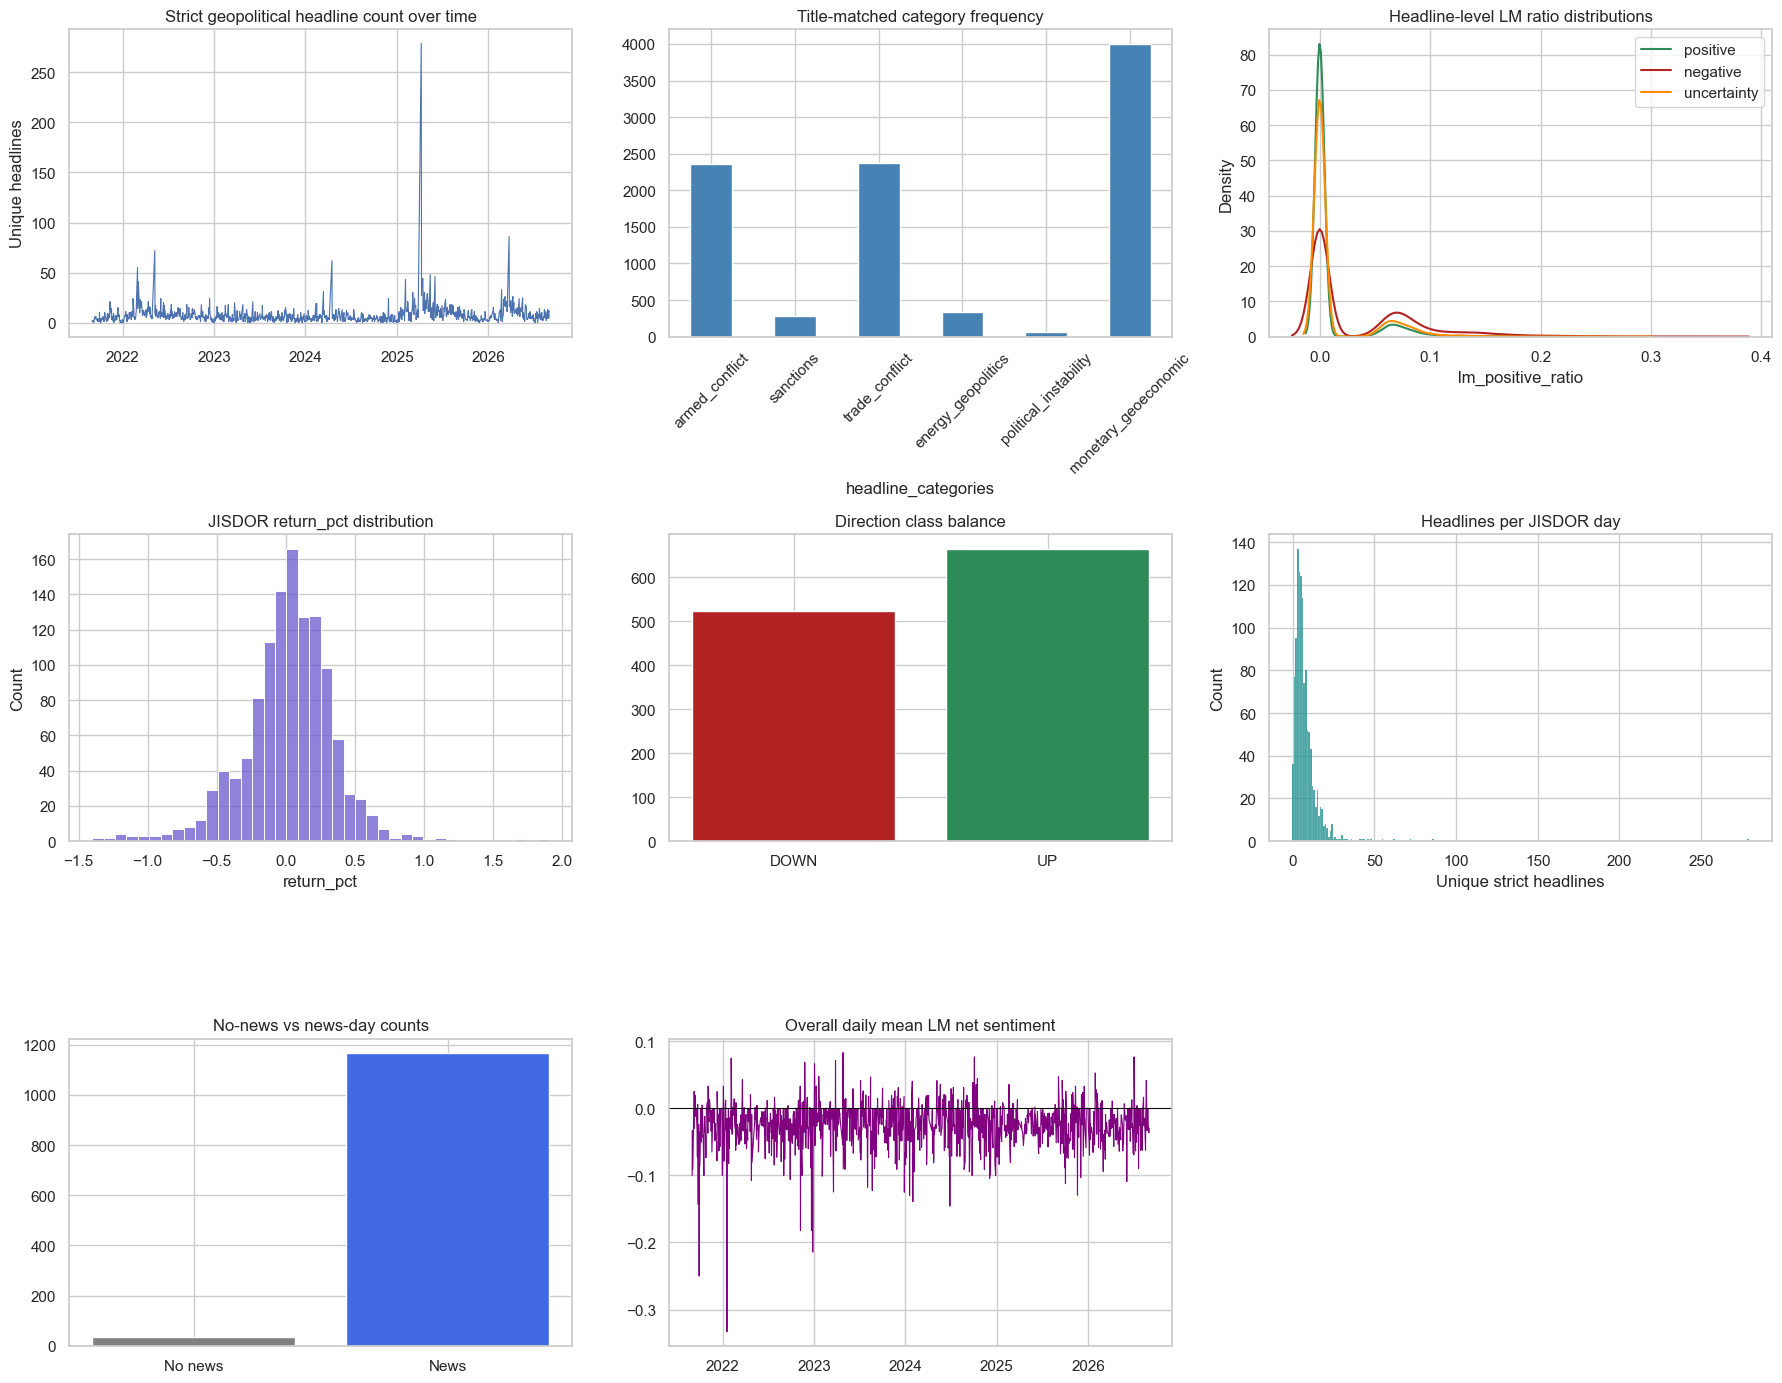

In [35]:
final_daily["return_lag_1"] = final_daily["return_pct"].shift(1)
final_daily["return_lag_2"] = final_daily["return_pct"].shift(2)
final_daily["return_lag_3"] = final_daily["return_pct"].shift(3)
final_daily["return_lag_5"] = final_daily["return_pct"].shift(5)

if "change_idr" in final_daily.columns:
    final_daily["change_lag_1"] = final_daily["change_idr"].shift(1)
else:
    final_daily["change_lag_1"] = np.nan

past_returns = final_daily["return_pct"].shift(1)
final_daily["rolling_return_mean_3"] = past_returns.rolling(3, min_periods=3).mean()
final_daily["rolling_return_mean_5"] = past_returns.rolling(5, min_periods=5).mean()
final_daily["rolling_volatility_5"] = past_returns.rolling(5, min_periods=5).std(ddof=0)
final_daily["rolling_volatility_10"] = past_returns.rolling(10, min_periods=10).std(ddof=0)

financial_feature_columns = [
    "return_lag_1",
    "return_lag_2",
    "return_lag_3",
    "return_lag_5",
    "change_lag_1",
    "rolling_return_mean_3",
    "rolling_return_mean_5",
    "rolling_volatility_5",
    "rolling_volatility_10",
]

strict_model_mask = (
    final_daily["direction"].notna()
    & final_daily[financial_feature_columns].notna().all(axis=1)
)
modeling_daily = final_daily.loc[strict_model_mask].copy()
modeling_daily["direction"] = modeling_daily["direction"].astype(int)

print(f"Full daily audit rows retained: {len(final_daily):,}")
print(f"Strict binary modeling rows: {len(modeling_daily):,}")
display(modeling_daily["split"].value_counts().reindex(["train", "validation", "test"]).to_frame("rows"))

# Descriptive visualizations requested for the data and NLP features.
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

axes[0, 0].plot(final_daily["date"], final_daily["news_count"], linewidth=0.8)
axes[0, 0].set_title("Strict geopolitical headline count over time")
axes[0, 0].set_ylabel("Unique headlines")

category_counts_article.plot(kind="bar", ax=axes[0, 1], color="steelblue")
axes[0, 1].set_title("Title-matched category frequency")
axes[0, 1].tick_params(axis="x", rotation=45)

for column, color in [
    ("lm_positive_ratio", "seagreen"),
    ("lm_negative_ratio", "firebrick"),
    ("lm_uncertainty_ratio", "darkorange"),
]:
    sns.kdeplot(
        strict_headlines[column],
        ax=axes[0, 2],
        label=column.replace("lm_", "").replace("_ratio", ""),
        color=color,
        warn_singular=False,
    )
axes[0, 2].set_title("Headline-level LM ratio distributions")
axes[0, 2].legend()

sns.histplot(jisdor_daily["return_pct"].dropna(), bins=40, ax=axes[1, 0], color="slateblue")
axes[1, 0].set_title("JISDOR return_pct distribution")

direction_counts = (
    jisdor_daily["direction"].dropna().astype(int).value_counts().reindex([0, 1], fill_value=0)
)
axes[1, 1].bar(["DOWN", "UP"], direction_counts.values, color=["firebrick", "seagreen"])
axes[1, 1].set_title("Direction class balance")

sns.histplot(final_daily["news_count"], discrete=True, ax=axes[1, 2], color="teal")
axes[1, 2].set_title("Headlines per JISDOR day")
axes[1, 2].set_xlabel("Unique strict headlines")

news_day_counts = pd.Series({
    "No news": int(final_daily["has_news"].eq(0).sum()),
    "News": int(final_daily["has_news"].eq(1).sum()),
})
axes[2, 0].bar(news_day_counts.index, news_day_counts.values, color=["gray", "royalblue"])
axes[2, 0].set_title("No-news vs news-day counts")

axes[2, 1].plot(
    final_daily["date"],
    final_daily["lm_net_mean"],
    linewidth=0.8,
    color="purple",
)
axes[2, 1].axhline(0, color="black", linewidth=0.7)
axes[2, 1].set_title("Overall daily mean LM net sentiment")

axes[2, 2].axis("off")
fig.tight_layout()
plt.show()

## 15. Naive Baseline

The naive prediction for a current trading day is the previous actual trading day's observed direction. If the immediately previous return is zero or missing, the naive prediction is unavailable and that row is omitted from naive metrics. Learned models are evaluated on the common strict modeling rows.

In [36]:
def classification_report_row(y_true, y_pred, model_name: str, split_name: str) -> dict:
    """Return all required classification metrics with a fixed DOWN/UP label order."""
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    return {
        "model": model_name,
        "split": split_name,
        "n_eval": len(y_true),
        "directional_accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=[0, 1]),
    }

naive_source = final_daily[["date", "direction"]].copy()
naive_source["naive_prediction"] = naive_source["direction"].shift(1)
modeling_with_naive = modeling_daily.merge(
    naive_source[["date", "naive_prediction"]],
    on="date",
    how="left",
    validate="one_to_one",
)

naive_results = {}
prediction_frames = {}
for split_name in ["validation", "test"]:
    evaluation = modeling_with_naive.loc[
        modeling_with_naive["split"].eq(split_name)
        & modeling_with_naive["naive_prediction"].notna()
    ]
    y_true = evaluation["direction"].astype(int)
    y_pred = evaluation["naive_prediction"].astype(int)
    naive_results[split_name] = classification_report_row(
        y_true, y_pred, "Naive previous direction", split_name
    )
    prediction_frames[(split_name, "Naive")] = (y_true.to_numpy(), y_pred.to_numpy())

display(pd.DataFrame([
    {key: value for key, value in row.items() if key != "confusion_matrix"}
    for row in naive_results.values()
]))
print("Validation confusion matrix [rows=true, columns=predicted; labels DOWN, UP]:")
print(naive_results["validation"]["confusion_matrix"])
print("Test confusion matrix:")
print(naive_results["test"]["confusion_matrix"])

,model,split,n_eval,directional_accuracy,f1,precision,recall
0,Naive previous direction,validation,176,0.511364,0.547368,0.541667,0.553191
1,Naive previous direction,test,173,0.554913,0.620690,0.617647,0.623762


Validation confusion matrix [rows=true, columns=predicted; labels DOWN, UP]:
[[38 44]
 [42 52]]
Test confusion matrix:
[[33 39]
 [38 63]]


## 16. Financial-Only Baseline

Logistic regression is scaled within a pipeline. During tuning, preprocessing and the model are fitted only on training dates. A small, pre-specified grid of regularization strengths and class-weight settings is ranked by validation directional accuracy, then validation F1, then stronger regularization as a deterministic tie-breaker.

In [37]:
train_modeling = modeling_daily.loc[modeling_daily["split"].eq("train")].copy()
validation_modeling = modeling_daily.loc[modeling_daily["split"].eq("validation")].copy()
test_modeling = modeling_daily.loc[modeling_daily["split"].eq("test")].copy()

C_GRID = [0.01, 0.1, 1.0, 10.0]
CLASS_WEIGHT_GRID = [None, "balanced"]

def make_logistic_pipeline(C: float, class_weight):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=C,
            class_weight=class_weight,
            max_iter=2_000,
            solver="liblinear",
            random_state=RANDOM_STATE,
        )),
    ])

def tune_logistic(feature_columns: list[str], model_name: str):
    """Tune on validation only; return the locked parameters, table, and predictions."""
    records = []
    fitted_candidates = {}
    X_train = train_modeling[feature_columns]
    y_train = train_modeling["direction"]
    X_validation = validation_modeling[feature_columns]
    y_validation = validation_modeling["direction"]

    for C in C_GRID:
        for class_weight in CLASS_WEIGHT_GRID:
            pipeline = make_logistic_pipeline(C, class_weight)
            pipeline.fit(X_train, y_train)
            predictions = pipeline.predict(X_validation)
            metrics = classification_report_row(
                y_validation, predictions, model_name, "validation"
            )
            record = {
                **{key: value for key, value in metrics.items() if key != "confusion_matrix"},
                "C": C,
                "class_weight": "none" if class_weight is None else class_weight,
            }
            records.append(record)
            fitted_candidates[(C, class_weight)] = (pipeline, predictions, metrics)

    tuning_table = (
        pd.DataFrame(records)
        .sort_values(
            ["directional_accuracy", "f1", "C"],
            ascending=[False, False, True],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )
    best_row = tuning_table.iloc[0]
    locked_weight = None if best_row["class_weight"] == "none" else best_row["class_weight"]
    locked_key = (float(best_row["C"]), locked_weight)
    best_pipeline, best_predictions, best_metrics = fitted_candidates[locked_key]
    locked_params = {"C": locked_key[0], "class_weight": locked_key[1]}
    return locked_params, tuning_table, best_pipeline, best_predictions, best_metrics

financial_params, financial_tuning, financial_train_model, financial_val_pred, financial_val_metrics = tune_logistic(
    financial_feature_columns,
    "Financial-only",
)
prediction_frames[("validation", "Financial-only")] = (
    validation_modeling["direction"].to_numpy(),
    financial_val_pred,
)

print("Locked financial-only parameters:", financial_params)
display(financial_tuning.head(8))

Locked financial-only parameters: {'C': 0.01, 'class_weight': None}


,model,split,n_eval,directional_accuracy,f1,precision,recall,C,class_weight
0,Financial-only,validation,178,0.544944,0.679842,0.544304,0.905263,0.01,none
1,Financial-only,validation,178,0.544944,0.677291,0.544872,0.894737,0.10,none
2,Financial-only,validation,178,0.539326,0.672000,0.541935,0.884211,1.00,none
3,Financial-only,validation,178,0.539326,0.672000,0.541935,0.884211,10.00,none
4,Financial-only,validation,178,0.505618,0.516484,0.540230,0.494737,10.00,balanced
5,Financial-only,validation,178,0.500000,0.513661,0.534091,0.494737,1.00,balanced
6,Financial-only,validation,178,0.494382,0.505495,0.528736,0.484211,0.01,balanced
7,Financial-only,validation,178,0.494382,0.505495,0.528736,0.484211,0.10,balanced


## 17. NLP-Only Model

The NLP-only model receives unique-news counts, the has_news indicator, six category counts, overall and category-level LM aggregates, and overall and category-level SVD aggregates. It receives no JISDOR lag or rolling feature.

In [38]:
nlp_params, nlp_tuning, nlp_train_model, nlp_val_pred, nlp_val_metrics = tune_logistic(
    nlp_feature_columns,
    "NLP-only",
)
prediction_frames[("validation", "NLP-only")] = (
    validation_modeling["direction"].to_numpy(),
    nlp_val_pred,
)

print(f"NLP feature count: {len(nlp_feature_columns)}")
print("Locked NLP-only parameters:", nlp_params)
display(nlp_tuning.head(8))

NLP feature count: 246
Locked NLP-only parameters: {'C': 10.0, 'class_weight': None}


,model,split,n_eval,directional_accuracy,f1,precision,recall,C,class_weight
0,NLP-only,validation,178,0.500000,0.460606,0.542857,0.400000,10.00,none
1,NLP-only,validation,178,0.500000,0.447205,0.545455,0.378947,1.00,none
2,NLP-only,validation,178,0.500000,0.440252,0.546875,0.368421,10.00,balanced
3,NLP-only,validation,178,0.483146,0.386667,0.527273,0.305263,0.10,balanced
4,NLP-only,validation,178,0.471910,0.426829,0.507246,0.368421,0.10,none
5,NLP-only,validation,178,0.466292,0.437870,0.500000,0.389474,0.01,none
6,NLP-only,validation,178,0.466292,0.387097,0.500000,0.315789,0.01,balanced
7,NLP-only,validation,178,0.460674,0.360000,0.490909,0.284211,1.00,balanced


## 18. Combined Financial + NLP Model

The combined model is the central comparison. It uses the union of historical financial predictors and daily headline-derived predictors. Improvement over the financial-only baseline would be evidence of incremental predictive value, not causality.

In [39]:
combined_feature_columns = [*financial_feature_columns, *nlp_feature_columns]

combined_params, combined_tuning, combined_train_model, combined_val_pred, combined_val_metrics = tune_logistic(
    combined_feature_columns,
    "Financial + NLP",
)
prediction_frames[("validation", "Financial + NLP")] = (
    validation_modeling["direction"].to_numpy(),
    combined_val_pred,
)

print(f"Combined feature count: {len(combined_feature_columns)}")
print("Locked combined-model parameters:", combined_params)
display(combined_tuning.head(8))

Combined feature count: 255
Locked combined-model parameters: {'C': 10.0, 'class_weight': None}


,model,split,n_eval,directional_accuracy,f1,precision,recall,C,class_weight
0,Financial + NLP,validation,178,0.511236,0.466258,0.558824,0.400000,10.00,none
1,Financial + NLP,validation,178,0.511236,0.452830,0.562500,0.378947,10.00,balanced
2,Financial + NLP,validation,178,0.483146,0.417722,0.523810,0.347368,1.00,none
3,Financial + NLP,validation,178,0.477528,0.367347,0.519231,0.284211,1.00,balanced
4,Financial + NLP,validation,178,0.471910,0.453488,0.506494,0.410526,0.01,none
5,Financial + NLP,validation,178,0.460674,0.421687,0.492958,0.368421,0.10,none
6,Financial + NLP,validation,178,0.460674,0.384615,0.491803,0.315789,0.01,balanced
7,Financial + NLP,validation,178,0.449438,0.363636,0.474576,0.294737,0.10,balanced


## 19. Validation and Model Selection

Validation data are used to lock regularization and class weighting separately for each pre-specified feature set. The SVD dimension and feature definitions were fixed before modeling. The test set has not been used in any transformation fitting, hyperparameter choice, or feature-set decision.

In [40]:
validation_results = [
    naive_results["validation"],
    financial_val_metrics,
    nlp_val_metrics,
    combined_val_metrics,
]
validation_table = pd.DataFrame([
    {key: value for key, value in row.items() if key != "confusion_matrix"}
    for row in validation_results
]).sort_values(["directional_accuracy", "f1"], ascending=False)

display(validation_table)
print("All methodology and hyperparameters are now locked before test evaluation.")

,model,split,n_eval,directional_accuracy,f1,precision,recall
1,Financial-only,validation,178,0.544944,0.679842,0.544304,0.905263
0,Naive previous direction,validation,176,0.511364,0.547368,0.541667,0.553191
3,Financial + NLP,validation,178,0.511236,0.466258,0.558824,0.400000
2,NLP-only,validation,178,0.500000,0.460606,0.542857,0.400000


All methodology and hyperparameters are now locked before test evaluation.


## 20. Final Test Evaluation

Each learned specification is refitted once on train + validation using its locked validation-selected hyperparameters, then evaluated once on the held-out test period. Directional Accuracy is primary; F1, precision, recall, and confusion matrices are also reported.

,model,split,n_eval,directional_accuracy,f1,precision,recall
1,Financial-only,test,177,0.593220,0.727273,0.600000,0.923077
3,Financial + NLP,test,177,0.564972,0.638498,0.623853,0.653846
0,Naive previous direction,test,173,0.554913,0.620690,0.617647,0.623762
2,NLP-only,test,177,0.542373,0.626728,0.601770,0.653846


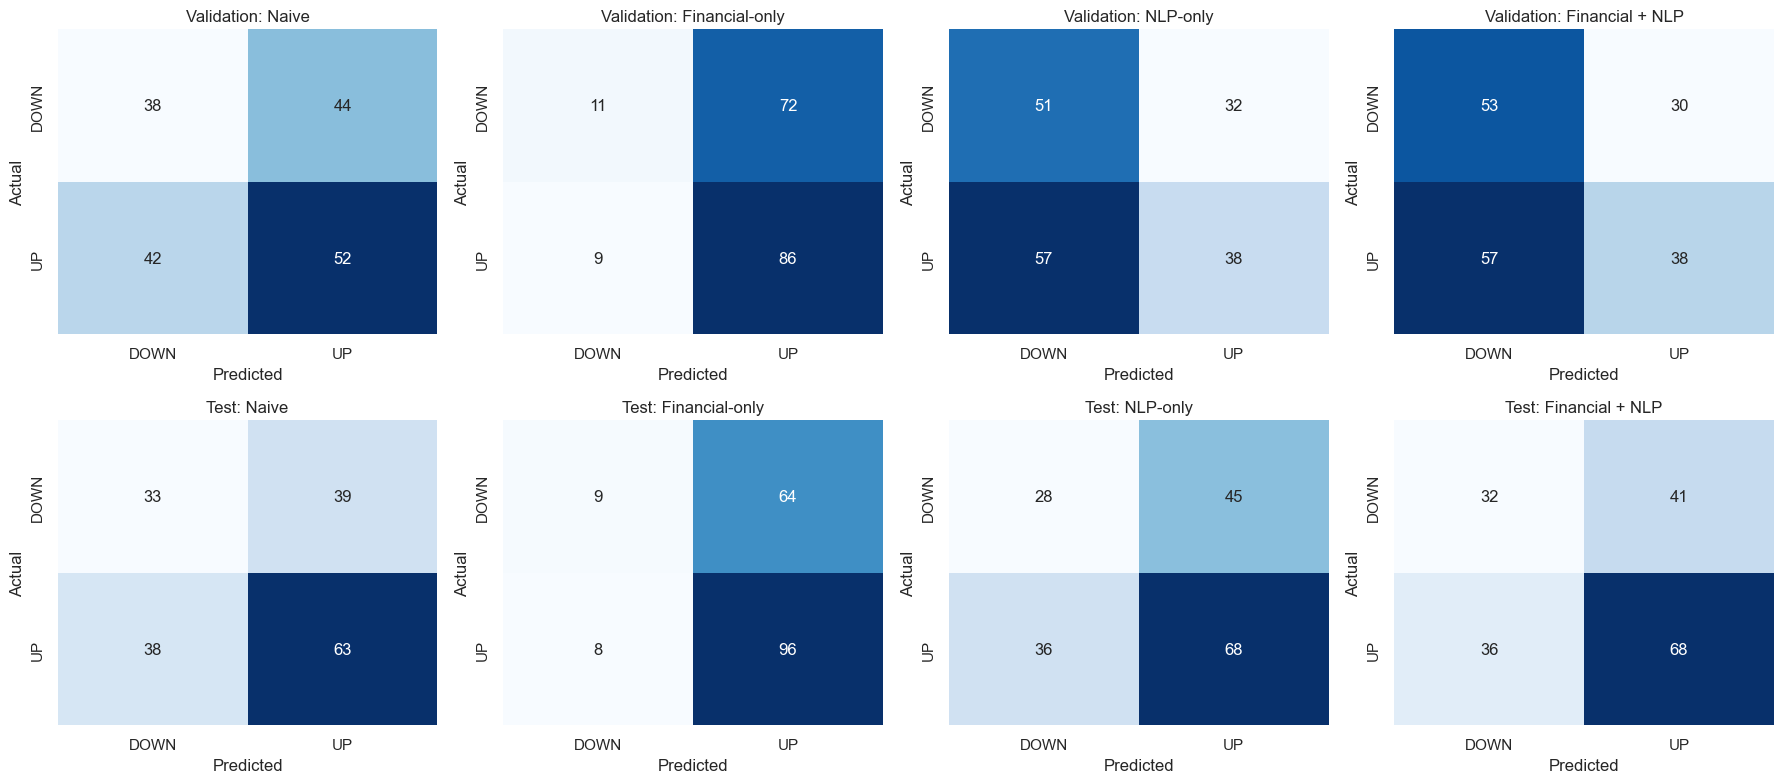

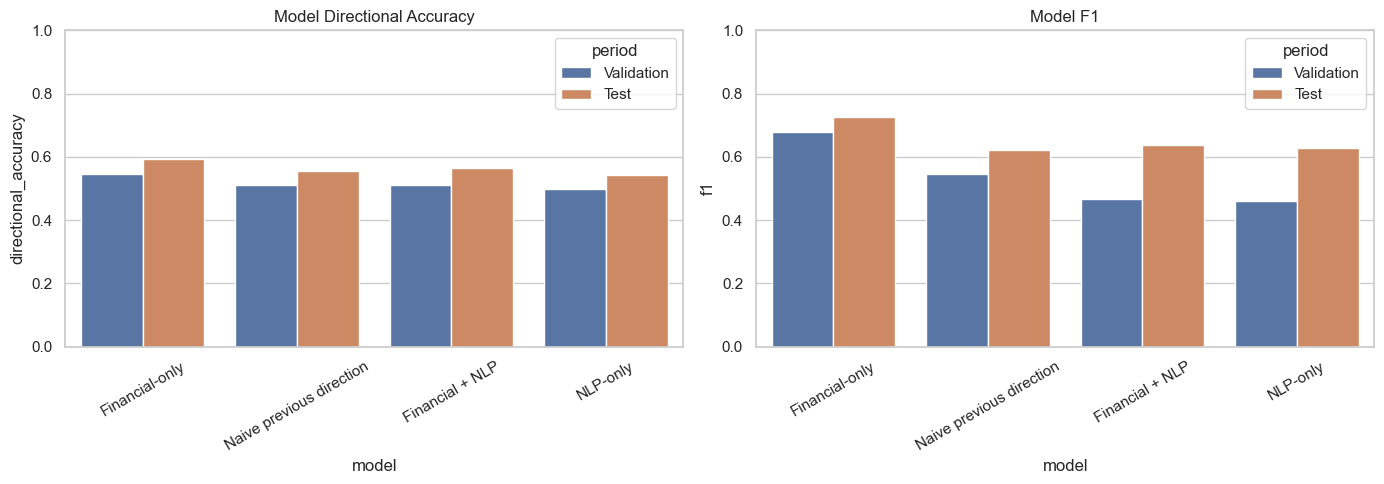

In [41]:
train_validation_modeling = modeling_daily.loc[
    modeling_daily["split"].isin(["train", "validation"])
].copy()

def fit_final_and_evaluate(
    feature_columns: list[str],
    locked_params: dict,
    model_name: str,
):
    final_model = make_logistic_pipeline(**locked_params)
    final_model.fit(
        train_validation_modeling[feature_columns],
        train_validation_modeling["direction"],
    )
    predictions = final_model.predict(test_modeling[feature_columns])
    metrics = classification_report_row(
        test_modeling["direction"],
        predictions,
        model_name,
        "test",
    )
    return final_model, predictions, metrics

financial_final_model, financial_test_pred, financial_test_metrics = fit_final_and_evaluate(
    financial_feature_columns, financial_params, "Financial-only"
)
nlp_final_model, nlp_test_pred, nlp_test_metrics = fit_final_and_evaluate(
    nlp_feature_columns, nlp_params, "NLP-only"
)
combined_final_model, combined_test_pred, combined_test_metrics = fit_final_and_evaluate(
    combined_feature_columns, combined_params, "Financial + NLP"
)

prediction_frames[("test", "Financial-only")] = (
    test_modeling["direction"].to_numpy(), financial_test_pred
)
prediction_frames[("test", "NLP-only")] = (
    test_modeling["direction"].to_numpy(), nlp_test_pred
)
prediction_frames[("test", "Financial + NLP")] = (
    test_modeling["direction"].to_numpy(), combined_test_pred
)

test_results = [
    naive_results["test"],
    financial_test_metrics,
    nlp_test_metrics,
    combined_test_metrics,
]
test_table = pd.DataFrame([
    {key: value for key, value in row.items() if key != "confusion_matrix"}
    for row in test_results
]).sort_values(["directional_accuracy", "f1"], ascending=False)
display(test_table)

# Validation and test confusion matrices for all four specifications.
model_display_order = ["Naive", "Financial-only", "NLP-only", "Financial + NLP"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for row_index, split_name in enumerate(["validation", "test"]):
    for column_index, model_name in enumerate(model_display_order):
        y_true, y_pred = prediction_frames[(split_name, model_name)]
        matrix = confusion_matrix(y_true, y_pred, labels=[0, 1])
        sns.heatmap(
            matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            ax=axes[row_index, column_index],
            xticklabels=["DOWN", "UP"],
            yticklabels=["DOWN", "UP"],
        )
        axes[row_index, column_index].set_title(f"{split_name.title()}: {model_name}")
        axes[row_index, column_index].set_xlabel("Predicted")
        axes[row_index, column_index].set_ylabel("Actual")
fig.tight_layout()
plt.show()

# Side-by-side model comparisons.
comparison_plot = pd.concat([
    validation_table.assign(period="Validation"),
    test_table.assign(period="Test"),
], ignore_index=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(
    data=comparison_plot,
    x="model",
    y="directional_accuracy",
    hue="period",
    ax=axes[0],
)
axes[0].set_title("Model Directional Accuracy")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_ylim(0, 1)

sns.barplot(
    data=comparison_plot,
    x="model",
    y="f1",
    hue="period",
    ax=axes[1],
)
axes[1].set_title("Model F1")
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_ylim(0, 1)
fig.tight_layout()
plt.show()

## 21. Leakage Audit

Titles are flagged, but not automatically deleted, when they directly describe an FX or currency movement. This audit is performed after the one-time test evaluation so it cannot be used to tune the reported test result. A separate future robustness study could rebuild all training-only text transformations after excluding flagged titles.

In [42]:
fx_leakage_phrases = [
    "dollar rises",
    "dollar falls",
    "dollar strengthens",
    "dollar weakens",
    "rupiah strengthens",
    "rupiah weakens",
    "exchange rate rises",
    "exchange rate falls",
    "currency gains",
    "currency drops",
]
fx_leakage_pattern = re.compile(
    r"(?<!\w)(?:" + "|".join(re.escape(phrase) for phrase in fx_leakage_phrases) + r")(?!\w)",
    flags=re.IGNORECASE,
)
headlines["potential_fx_leakage"] = headlines["title"].fillna("").str.contains(
    fx_leakage_pattern, regex=True
)
strict_headlines["potential_fx_leakage"] = strict_headlines["title"].fillna("").str.contains(
    fx_leakage_pattern, regex=True
)

leakage_columns = [
    column for column in
    ["title", "effective_trade_date", "headline_categories", "matched_categories"]
    if column in headlines.columns
]
potential_leakage = headlines.loc[headlines["potential_fx_leakage"], leakage_columns]

print(f"Potentially leaking aligned headlines: {len(potential_leakage):,}")
print(
    "Potentially leaking strict title-matched headlines:",
    int(strict_headlines["potential_fx_leakage"].sum()),
)
display(potential_leakage.head(25))

Potentially leaking aligned headlines: 1
Potentially leaking strict title-matched headlines: 1


,title,effective_trade_date,headline_categories,matched_categories
340,Japan leads losses in Asia-Pacific; New Zealan...,2021-11-24,[monetary_geoeconomic],"[""monetary_geoeconomic""]"


## 22. Save Final Daily Modeling Dataset

Before saving, explicit QA checks verify calendar preservation, date order, chronological separation, training-only TF–IDF/SVD fitting, leakage-safe model inputs, unique-article news counts, and expected multi-label behavior. Only new Task 2 output paths are written.

In [43]:
# 1–4: master-calendar preservation and date integrity.
assert len(final_daily) == len(jisdor_daily)
assert final_daily["date"].is_unique
assert final_daily["date"].is_monotonic_increasing
pd.testing.assert_series_equal(
    final_daily["date"].reset_index(drop=True),
    jisdor_daily["date"].reset_index(drop=True),
    check_names=False,
)
assert final_daily["date"].dt.dayofweek.lt(5).all(), "Source JISDOR calendar unexpectedly contains weekends."

# 5–6: strict chronological partitions.
assert train_dates.max() < validation_dates.min()
assert validation_dates.max() < test_dates.min()

# 7: exact indices used for TF-IDF fitting are training headlines only.
expected_tfidf_fit_indices = strict_headlines.index[strict_headlines["split"].eq("train")]
assert set(tfidf_fit_indices) == set(expected_tfidf_fit_indices)
assert strict_headlines.loc[tfidf_fit_indices, "effective_trade_date"].max() <= train_dates.max()

# 8: SVD was fitted once on the training TF-IDF matrix.
assert hasattr(svd, "components_")
assert svd.components_.shape == (n_svd_components, train_tfidf.shape[1])
assert train_tfidf.shape == tfidf_matrices["train"].shape

# 9: same-day target and rate fields are excluded from every model input list.
for feature_set in [
    financial_feature_columns,
    nlp_feature_columns,
    combined_feature_columns,
]:
    assert "return_pct" not in feature_set
    assert "direction" not in feature_set
    assert "jisdor" not in feature_set
    assert "change_idr" not in feature_set

# 10: news_count exactly equals unique strict articles per day.
qa_unique_counts = (
    strict_headlines.groupby("effective_trade_date")["article_key"].nunique()
    .reindex(final_daily["date"], fill_value=0)
    .to_numpy(dtype=int)
)
assert np.array_equal(final_daily["news_count"].to_numpy(), qa_unique_counts)

# 11: multi-label counts can exceed news_count and can never be smaller in total.
category_count_sum = final_daily[category_count_columns].sum(axis=1)
assert (category_count_sum >= final_daily["news_count"]).all()
print(
    "Days where multi-label category total exceeds news_count:",
    int(category_count_sum.gt(final_daily["news_count"]).sum()),
)

# Save dates in ISO format without mutating the in-memory datetime columns.
final_daily_output = final_daily.copy()
final_daily_output["date"] = final_daily_output["date"].dt.strftime("%Y-%m-%d")

modeling_output = modeling_daily.copy()
modeling_output["date"] = modeling_output["date"].dt.strftime("%Y-%m-%d")

strict_headlines_output = strict_headlines.copy()
strict_headlines_output["effective_trade_date"] = strict_headlines_output[
    "effective_trade_date"
].dt.strftime("%Y-%m-%d")
strict_headlines_output["headline_categories"] = strict_headlines_output[
    "headline_categories"
].map(lambda values: json.dumps(values, ensure_ascii=False))
strict_headlines_output["headline_category_matches"] = strict_headlines_output[
    "headline_category_matches"
].map(lambda value: json.dumps(value, ensure_ascii=False, sort_keys=True))

for output_path in [FINAL_DAILY_PATH, MODELING_PATH, DIRECT_MATCH_PATH]:
    if output_path in {HEADLINE_PATH, JISDOR_DAILY_PATH}:
        raise AssertionError("A Task 2 output path would overwrite a Task 1 source file.")
    output_path.parent.mkdir(parents=True, exist_ok=True)

final_daily_output.to_csv(FINAL_DAILY_PATH, index=False)
modeling_output.to_csv(MODELING_PATH, index=False)
strict_headlines_output.to_csv(DIRECT_MATCH_PATH, index=False)

print("All QA checks passed.")
print(f"Saved: {FINAL_DAILY_PATH.relative_to(ROOT)} — {final_daily_output.shape}")
print(f"Saved: {MODELING_PATH.relative_to(ROOT)} — {modeling_output.shape}")
print(f"Saved: {DIRECT_MATCH_PATH.relative_to(ROOT)} — {strict_headlines_output.shape}")

Days where multi-label category total exceeds news_count: 232
All QA checks passed.
Saved: data\processed\cnbc_jisdor_nlp_daily.csv — (1202, 262)
Saved: data\processed\cnbc_jisdor_nlp_modeling.csv — (1178, 262)
Saved: data\processed\cnbc_headlines_direct_match.csv — (9008, 56)


## 23. Final Summary

The conclusion is descriptive and predictive only. It does not claim that CNBC headlines cause exchange-rate movements.

In [44]:
test_metrics_by_model = {row["model"]: row for row in test_results}
financial_test_accuracy = test_metrics_by_model["Financial-only"]["directional_accuracy"]
combined_test_accuracy = test_metrics_by_model["Financial + NLP"]["directional_accuracy"]
accuracy_difference = combined_test_accuracy - financial_test_accuracy

if accuracy_difference > 0:
    conclusion = (
        "On the held-out test period, the combined model improves Directional Accuracy "
        f"over the financial-only baseline by {accuracy_difference:.3f}. This is evidence "
        "of incremental predictive value in this sample, not causality."
    )
elif accuracy_difference < 0:
    conclusion = (
        "On the held-out test period, the combined model does not improve Directional "
        f"Accuracy over the financial-only baseline (difference {accuracy_difference:.3f}). "
        "This sample therefore does not show incremental predictive value by that primary metric."
    )
else:
    conclusion = (
        "On the held-out test period, the combined and financial-only models have identical "
        "Directional Accuracy. There is no improvement in the primary metric."
    )

print("ARTICLE LEVEL")
print(f"- Total aligned CNBC headlines loaded: {len(headlines):,}")
print(f"- Strict direct-title taxonomy matches: {direct_count:,}")
print(
    f"- Headline date range: {headlines['effective_trade_date'].min().date()} "
    f"to {headlines['effective_trade_date'].max().date()}"
)
print(f"- Unique aligned headline-covered trading dates: {headlines['effective_trade_date'].nunique():,}")
print(f"- Unique strict headline-covered trading dates: {strict_headlines['effective_trade_date'].nunique():,}")

print("\nDAILY LEVEL")
print(f"- Total JISDOR trading days: {len(final_daily):,}")
print(f"- Days with news: {int(final_daily['has_news'].sum()):,}")
print(f"- Days without news: {int(final_daily['has_news'].eq(0).sum()):,}")
print(f"- Final daily NLP dataset shape: {final_daily.shape}")

print("\nTARGET")
print(f"- UP days: {target_audit['positive_return_days']:,}")
print(f"- DOWN days: {target_audit['negative_return_days']:,}")
print(f"- Zero-return days: {target_audit['zero_return_days']:,}")
print(f"- Missing-return days: {target_audit['missing_return_days']:,}")
print(f"- Final binary modeling rows: {len(modeling_daily):,}")

print("\nSPLITS")
for split_name in ["train", "validation", "test"]:
    rows = modeling_daily.loc[modeling_daily["split"].eq(split_name)]
    print(
        f"- {split_name.title()}: {rows['date'].min().date()} to "
        f"{rows['date'].max().date()}, {len(rows):,} modeling rows"
    )

print("\nFEATURES")
print(f"- TF-IDF vocabulary size: {tfidf_vocabulary_size:,}")
print(f"- SVD components: {n_svd_components}")
print(f"- NLP features: {len(nlp_feature_columns):,}")
print(f"- Financial features: {len(financial_feature_columns):,}")

print("\nMODELS — HELD-OUT TEST")
for model_name in [
    "Naive previous direction",
    "Financial-only",
    "NLP-only",
    "Financial + NLP",
]:
    row = test_metrics_by_model[model_name]
    print(
        f"- {model_name}: Directional Accuracy={row['directional_accuracy']:.3f}, "
        f"F1={row['f1']:.3f}, Precision={row['precision']:.3f}, "
        f"Recall={row['recall']:.3f}, n={row['n_eval']}"
    )

print("\nCONCLUSION")
print(conclusion)

ARTICLE LEVEL
- Total aligned CNBC headlines loaded: 10,997
- Strict direct-title taxonomy matches: 9,008
- Headline date range: 2021-09-01 to 2026-09-01
- Unique aligned headline-covered trading dates: 1,185
- Unique strict headline-covered trading dates: 1,166

DAILY LEVEL
- Total JISDOR trading days: 1,202
- Days with news: 1,166
- Days without news: 36
- Final daily NLP dataset shape: (1202, 262)

TARGET
- UP days: 665
- DOWN days: 523
- Zero-return days: 13
- Missing-return days: 1
- Final binary modeling rows: 1,178

SPLITS
- Train: 2021-09-16 to 2025-02-18, 823 modeling rows
- Validation: 2025-02-19 to 2025-11-21, 178 modeling rows
- Test: 2025-11-24 to 2026-09-01, 177 modeling rows

FEATURES
- TF-IDF vocabulary size: 6,413
- SVD components: 30
- NLP features: 246
- Financial features: 9

MODELS — HELD-OUT TEST
- Naive previous direction: Directional Accuracy=0.555, F1=0.621, Precision=0.618, Recall=0.624, n=173
- Financial-only: Directional Accuracy=0.593, F1=0.727, Precision=0